# Лабораторная работа 2

## Полносвязная нейронная сеть

Реализовать нейронную сеть, состоящую из двух полносвязных слоев и решающую задачу классификации на наборе данных из лабораторной работы 1.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scripts.classifiers.neural_net import TwoLayerNet

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0)
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'


def rel_error(x, y):
    """Возвращает относительную ошибку между двумя массивами."""
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))


1. Добавьте реализации методов класса TwoLayerNet . Проверьте вашу реализацию на модельных данных (Код приведен ниже).  

In [2]:
input_size = 4
hidden_size = 10
num_classes = 3
num_inputs = 5


def init_toy_model():
    np.random.seed(0)
    return TwoLayerNet(input_size, hidden_size, num_classes, std=1e-1)


def init_toy_data():
    np.random.seed(1)
    X = 10 * np.random.randn(num_inputs, input_size)
    y = np.array([0, 1, 2, 2, 1])
    return X, y


net = init_toy_model()
X, y = init_toy_data()


# Прямой проход: вычисление выхода сети

Реализуйте первую часть  метода TwoLayerNet.loss, вычисляющую оценки классов для входных данных. 

Сравните ваш выход сети с эталонными значениями. Ошибка должна быть очень маленькой (можете ориентироваться на значение < 1e-7) .

In [3]:
scores = net.loss(X)
print('Your scores:')
print(scores)
print()

correct_scores = np.asarray([
    [-0.81233741, -1.27654624, -0.70335995],
    [-0.17129677, -1.18803311, -0.47310444],
    [-0.51590475, -1.01354314, -0.8504215],
    [-0.15419291, -0.48629638, -0.52901952],
    [-0.00618733, -0.12435261, -0.15226949],
])
print('correct scores:')
print(correct_scores)
print()

print('Difference between your scores and correct scores:')
print(np.sum(np.abs(scores - correct_scores)))


Your scores:
[[-0.81233741 -1.27654624 -0.70335995]
 [-0.17129677 -1.18803311 -0.47310444]
 [-0.51590475 -1.01354314 -0.8504215 ]
 [-0.15419291 -0.48629638 -0.52901952]
 [-0.00618733 -0.12435261 -0.15226949]]

correct scores:
[[-0.81233741 -1.27654624 -0.70335995]
 [-0.17129677 -1.18803311 -0.47310444]
 [-0.51590475 -1.01354314 -0.8504215 ]
 [-0.15419291 -0.48629638 -0.52901952]
 [-0.00618733 -0.12435261 -0.15226949]]

Difference between your scores and correct scores:
3.6802720745909845e-08



# Прямой проход: вычисление loss

Реализуйте вторую часть метода, вычисляющую значение функции потерь. Сравните с эталоном. Ошибка должна быть очень маленькой (можете ориентироваться на значение < 1e-12) .

In [4]:
loss, _ = net.loss(X, y, reg=0.05)
correct_loss = 1.30378789133

print('Difference between your loss and correct loss:')
print(np.sum(np.abs(loss - correct_loss)))


Difference between your loss and correct loss:
1.7985612998927536e-13


# Обратный проход

Реализуйте третью часть метода loss. Используйте численную реализацию расчета градиента для проверки вашей реализации обратного прохода.  Если прямой и обратный проходы реализованы верно, то ошибка будет < 1e-8 для каждой из переменных W1, W2, b1, и b2. 


In [5]:
from scripts.gradient_check import eval_numerical_gradient

loss, grads = net.loss(X, y, reg=0.05)

for param_name in grads:
    f = lambda W: net.loss(X, y, reg=0.05)[0]
    param_grad_num = eval_numerical_gradient(f, net.params[param_name], verbose=False)
    print('%s max relative error: %e'
          % (param_name, rel_error(param_grad_num, grads[param_name])))


W2 max relative error: 3.440708e-09
b2 max relative error: 4.447625e-11
W1 max relative error: 3.561318e-09
b1 max relative error: 2.738421e-09


# Обучение нейронной сети на смоделированных данных

Реализуйте методы TwoLayerNet.train и TwoLayerNet.predict. Обучайте сеть до тех пор, пока значение loss не будет < 0.02.


Final training loss:  0.017149607938732093


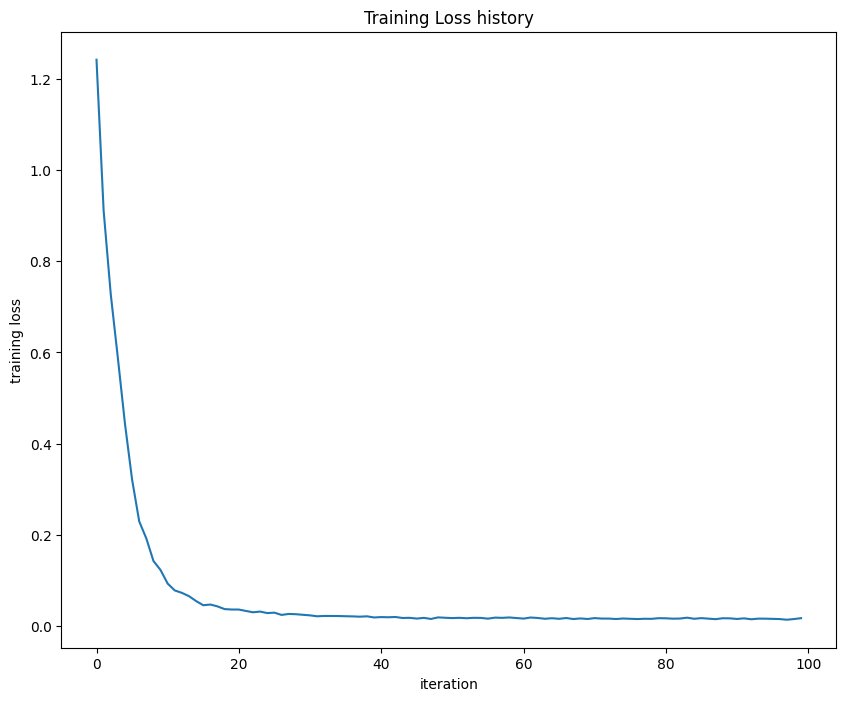

In [6]:
net = init_toy_model()
stats = net.train(X, y, X, y,
                  learning_rate=1e-1, reg=5e-6,
                  num_iters=100, verbose=False)

print('Final training loss: ', stats['loss_history'][-1])

plt.plot(stats['loss_history'])
plt.xlabel('iteration')
plt.ylabel('training loss')
plt.title('Training Loss history')
plt.show()


# Обучение нейронной сети на реальном наборе данных (CIFAR-10, MNIST)

Загрузите набор данных, соответствующий вашему варианту. 

Разделите данные на обучающую, тестовую и валидационную выборки.

Выполните предобработку данных, как в ЛР 1. 

Обучите нейронную сеть на ваших данных. 

При сдаче лабораторной работы объясните значения всех параметров метода train.

In [ ]:
from scripts.data_utils import load_CIFAR10

cifar10_dir = 'scripts/datasets/cifar-10-batches-py'

try:
    del X_train, y_train
    del X_test, y_test
    print('Clear previously loaded data.')
except NameError:
    pass

X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

print('Training data shape:   ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape:       ', X_test.shape)
print('Test labels shape:     ', y_test.shape)


c:\Users\tssvett\OneDrive\Рабочий стол\ИИ2026\part2\scripts\data_utils.py:15: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  return  pickle.load(f, encoding='latin1')


Training data shape:    (50000, 32, 32, 3)
Training labels shape:  (50000,)
Test data shape:        (10000, 32, 32, 3)
Test labels shape:      (10000,)


Параметры метода train: X - массив тренировочных данных (N, D); y - вектор меток классов (N,); X_val - массив валидационных данных; y_val - правильные ответы для валидационной выборки

In [ ]:
num_training = 49000
num_validation = 1000
num_test = 1000

X_val = X_train[num_training:num_training + num_validation]
y_val = y_train[num_training:num_training + num_validation]
X_train = X_train[:num_training]
y_train = y_train[:num_training]
X_test = X_test[:num_test]
y_test = y_test[:num_test]

mean_image = np.mean(X_train, axis=0)
X_train -= mean_image
X_val -= mean_image
X_test -= mean_image

X_train = X_train.reshape(num_training, -1)
X_val = X_val.reshape(num_validation, -1)
X_test = X_test.reshape(num_test, -1)

print('Train data shape:      ', X_train.shape)
print('Validation data shape: ', X_val.shape)
print('Test data shape:       ', X_test.shape)


Train data shape:       (49000, 3072)
Validation data shape:  (1000, 3072)
Test data shape:        (1000, 3072)


In [9]:
input_size = 32 * 32 * 3
hidden_size = 50
num_classes = 10

net = TwoLayerNet(input_size, hidden_size, num_classes)

stats = net.train(X_train, y_train, X_val, y_val,
                  num_iters=1000, batch_size=200,
                  learning_rate=1e-4, learning_rate_decay=0.95,
                  reg=0.25, verbose=True)

val_acc = (net.predict(X_val) == y_val).mean()
print('Validation accuracy: ', val_acc)


iteration 0 / 1000: loss 2.302954
iteration 100 / 1000: loss 2.302550
iteration 200 / 1000: loss 2.297648
iteration 300 / 1000: loss 2.259602
iteration 400 / 1000: loss 2.204170
iteration 500 / 1000: loss 2.118565
iteration 600 / 1000: loss 2.051535
iteration 700 / 1000: loss 1.988466
iteration 800 / 1000: loss 2.006591
iteration 900 / 1000: loss 1.951473
Validation accuracy:  0.287


Используя параметры по умолчанию, вы можете получить accuracy, примерно равный 0.29. 

Проведите настройку гиперпараметров для увеличения accuracy. Поэкспериментируйте со значениями гиперпараметров, например, с количеством скрытых слоев, количеством эпох, скорости обучения и др. Ваша цель - максимально увеличить accuracy полносвязной сети на валидационном наборе. Различные эксперименты приветствуются. Например, вы можете использовать методы для сокращения размерности признакового пространства (например, PCA), добавить dropout слои и др. 

Для лучшей модели вычислите acсuracy на тестовом наборе. 

Для отладки процесса обучения часто помогают графики изменения loss и accuracy в процессе обучения. Ниже приведен код построения таких графиков. 

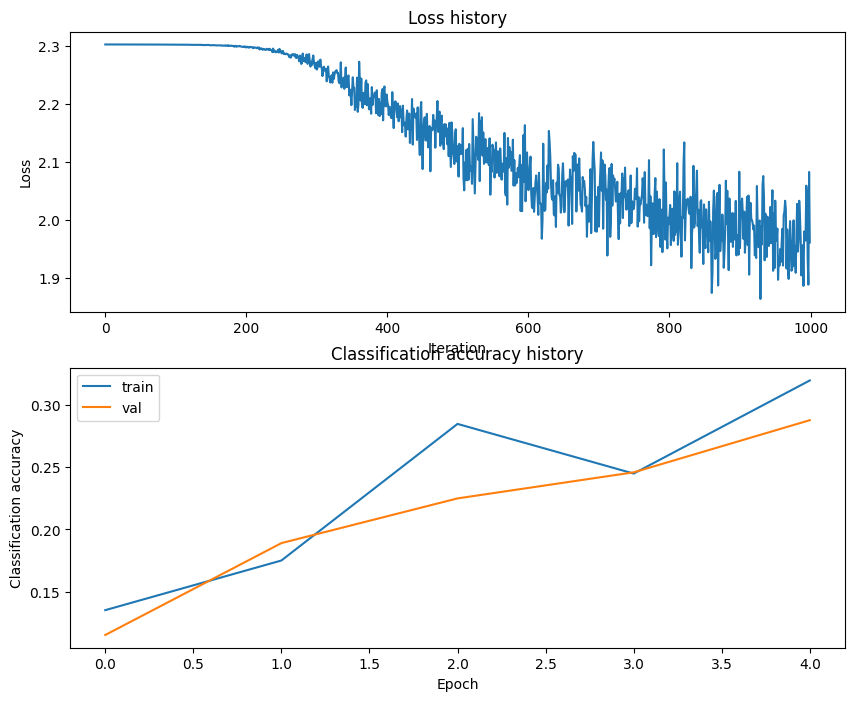

In [10]:
plt.subplot(2, 1, 1)
plt.plot(stats['loss_history'])
plt.title('Loss history')
plt.xlabel('Iteration')
plt.ylabel('Loss')

plt.subplot(2, 1, 2)
plt.plot(stats['train_acc_history'], label='train')
plt.plot(stats['val_acc_history'], label='val')
plt.title('Classification accuracy history')
plt.xlabel('Epoch')
plt.ylabel('Classification accuracy')
plt.legend()
plt.show()


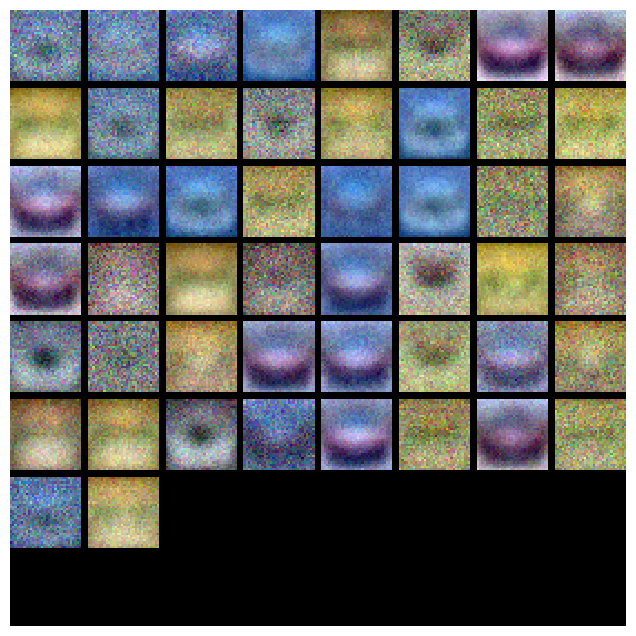

In [11]:
from scripts.vis_utils import visualize_grid


def show_net_weights(net):
    W1 = net.params['W1']
    W1 = W1.reshape(32, 32, 3, -1).transpose(3, 0, 1, 2)
    plt.imshow(visualize_grid(W1, padding=3).astype('uint8'))
    plt.gca().axis('off')
    plt.show()


show_net_weights(net)


In [12]:
# Поиск лучшей модели по сетке гиперпараметров
best_net = None
best_val_acc = -1
best_stats = None

learning_rates = [1e-3, 1.5e-3]
regularization_strengths = [0.1, 0.25, 0.5]
hidden_sizes = [50, 100]

for lr in learning_rates:
    for reg in regularization_strengths:
        for hs in hidden_sizes:
            net = TwoLayerNet(input_size, hs, num_classes)
            stats = net.train(X_train, y_train, X_val, y_val,
                              num_iters=1500, batch_size=200,
                              learning_rate=lr, learning_rate_decay=0.95,
                              reg=reg, verbose=False)

            val_acc = (net.predict(X_val) == y_val).mean()
            print(f'lr: {lr}, reg: {reg}, hidden_size: {hs}, accuracy: {val_acc:.4f}')

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_net = net
                best_stats = stats

print(f'\nЛучшая accuracy: {best_val_acc}')


lr: 0.001, reg: 0.1, hidden_size: 50, accuracy: 0.4850
lr: 0.001, reg: 0.1, hidden_size: 100, accuracy: 0.4940
lr: 0.001, reg: 0.25, hidden_size: 50, accuracy: 0.4820
lr: 0.001, reg: 0.25, hidden_size: 100, accuracy: 0.4740
lr: 0.001, reg: 0.5, hidden_size: 50, accuracy: 0.4840
lr: 0.001, reg: 0.5, hidden_size: 100, accuracy: 0.4890
lr: 0.0015, reg: 0.1, hidden_size: 50, accuracy: 0.4780
lr: 0.0015, reg: 0.1, hidden_size: 100, accuracy: 0.4680
lr: 0.0015, reg: 0.25, hidden_size: 50, accuracy: 0.4910
lr: 0.0015, reg: 0.25, hidden_size: 100, accuracy: 0.5150
lr: 0.0015, reg: 0.5, hidden_size: 50, accuracy: 0.4700
lr: 0.0015, reg: 0.5, hidden_size: 100, accuracy: 0.4840

Лучшая accuracy: 0.515


In [13]:
test_acc = (best_net.predict(X_test) == y_test).mean()
print('Test accuracy: ', test_acc)


Test accuracy:  0.511


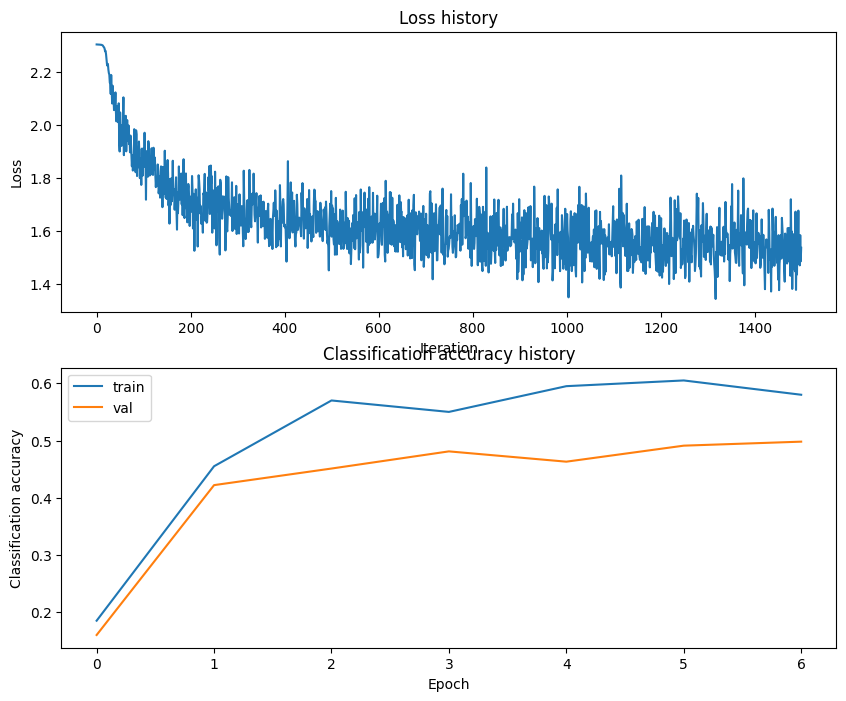

In [14]:
plt.subplot(2, 1, 1)
plt.plot(stats['loss_history'])
plt.title('Loss history')
plt.xlabel('Iteration')
plt.ylabel('Loss')

plt.subplot(2, 1, 2)
plt.plot(stats['train_acc_history'], label='train')
plt.plot(stats['val_acc_history'], label='val')
plt.title('Classification accuracy history')
plt.xlabel('Epoch')
plt.ylabel('Classification accuracy')
plt.legend()
plt.show()


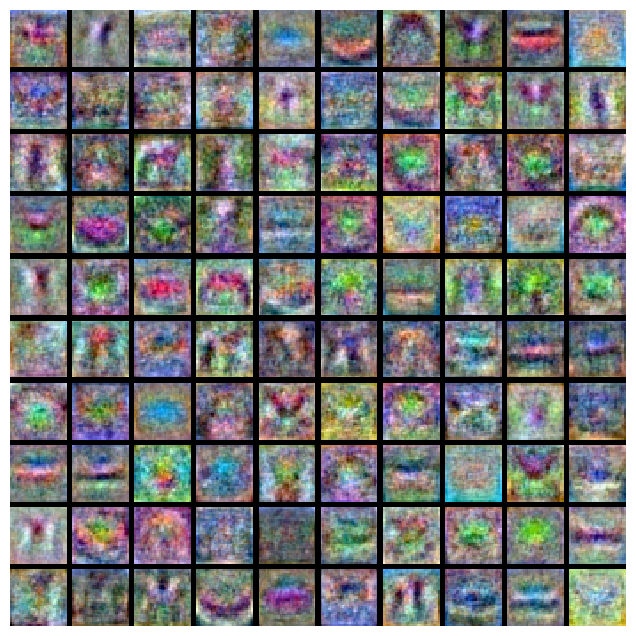

In [15]:
show_net_weights(best_net)


Сделайте выводы по результатам работы. 

**Прогон с гиперпараметрами по умолчанию** (hidden_size=50, lr=1e-4, reg=0,25, num_iters=1000) дал val-accuracy 28,7%. На графике видно, что loss падает очень медленно и остаётся высоким (с 2,30 до ~1,95), а веса первого слоя после обучения выглядят как шум — сеть не успела выделить полезные признаки. Основные причины недообучения — слишком малая скорость обучения и недостаточное число итераций.

**Подбор гиперпараметров** по сетке learning_rate, reg, hidden_size  при 1500 итерациях показал:

- увеличение lr на порядок (1e-4 -> 1e-3) радикально ускорило сходимость — почти все конфигурации дали val-accuracy в диапазоне 47–52%;
- увеличение скрытого слоя (50 -> 100) в среднем улучшает результат, но не монотонно;
- лучшая конфигурация: **lr=1,5e-3, reg=0,25, hidden_size=100** — val-accuracy **0,515**, test-accuracy **0,511**.

Веса лучшей модели уже не выглядят как шум — каждое «изображение» фильтра напоминает сглаженный шаблон класса (контуры машин, кошек, самолётов). Двухслойная полносвязная сеть почти удвоила точность относительно линейного SVM (38,1% -> 51,1% на тесте).